<a href="https://colab.research.google.com/github/cagan123/ML_for-begginers-code/blob/main/2-Regression/2-Data/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
from datetime import datetime
import numpy as np

# Use the raw GitHub URL for the CSV file
url = 'https://raw.githubusercontent.com/microsoft/ML-For-Beginners/main/2-Regression/data/US-pumpkins.csv'
pumpkins = pd.read_csv(url)

pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]


columns_to_select = ['Package', 'Low Price', 'High Price', 'Date', 'Variety']
pumpkins = pumpkins.loc[:, columns_to_select]


price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

month = pd.DatetimeIndex(pumpkins['Date']).month
day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)

new_pumpkins = pd.DataFrame({'Month': month,"DayOfYear": day_of_year, 'Variety': pumpkins['Variety'], 'Package': pumpkins['Package'], 'Low Price': pumpkins['Low Price'],'High Price': pumpkins['High Price'], 'Price': price})
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/(1 + 1/9)

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price/(1/2)
print(new_pumpkins)

      Month  DayOfYear    Variety               Package  Low Price  \
70        9        267   PIE TYPE  1 1/9 bushel cartons      15.00   
71        9        267   PIE TYPE  1 1/9 bushel cartons      18.00   
72       10        274   PIE TYPE  1 1/9 bushel cartons      18.00   
73       10        274   PIE TYPE  1 1/9 bushel cartons      17.00   
74       10        281   PIE TYPE  1 1/9 bushel cartons      15.00   
...     ...        ...        ...                   ...        ...   
1738      9        273  MINIATURE    1/2 bushel cartons      15.00   
1739      9        273  MINIATURE    1/2 bushel cartons      13.75   
1740      9        273  MINIATURE    1/2 bushel cartons      10.75   
1741      9        273  MINIATURE    1/2 bushel cartons      12.00   
1742      9        273  MINIATURE    1/2 bushel cartons      12.00   

      High Price  Price  
70          15.0  13.50  
71          18.0  16.20  
72          18.0  16.20  
73          17.0  15.30  
74          15.0  13.50  
...

/tmp/ipykernel_1285/2955729281.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)


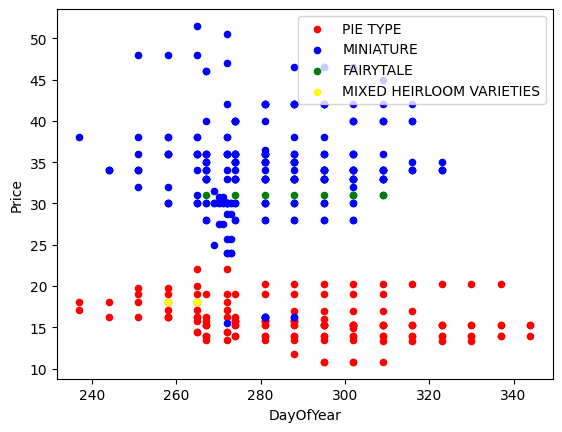

In [20]:
ax=None
colors = ['red','blue','green','yellow']
for i,var in enumerate(new_pumpkins['Variety'].unique()):
    df = new_pumpkins[new_pumpkins['Variety']==var]
    ax = df.plot.scatter('DayOfYear','Price',ax=ax,c=colors[i],label=var)

<Axes: xlabel='Variety'>

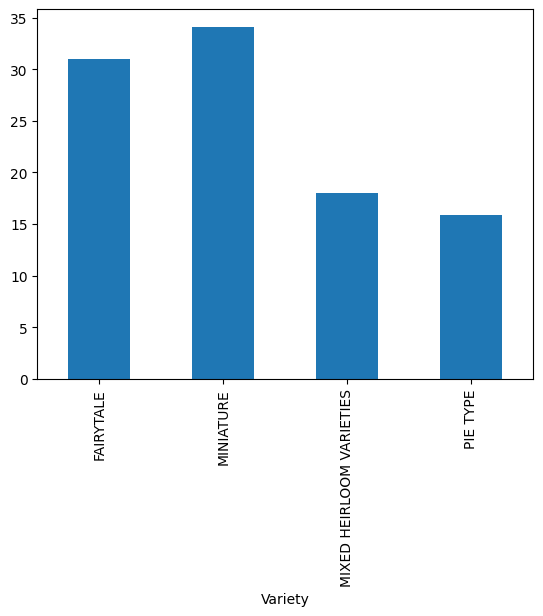

In [21]:
new_pumpkins.groupby('Variety')['Price'].mean().plot(kind='bar')

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 70 to 1630
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Month       144 non-null    int32  
 1   DayOfYear   144 non-null    int64  
 2   Variety     144 non-null    object 
 3   Package     144 non-null    object 
 4   Low Price   144 non-null    float64
 5   High Price  144 non-null    float64
 6   Price       144 non-null    float64
dtypes: float64(3), int32(1), int64(1), object(2)
memory usage: 8.4+ KB


/tmp/ipykernel_1285/4136592454.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pie_pumpkins.dropna(inplace=True)


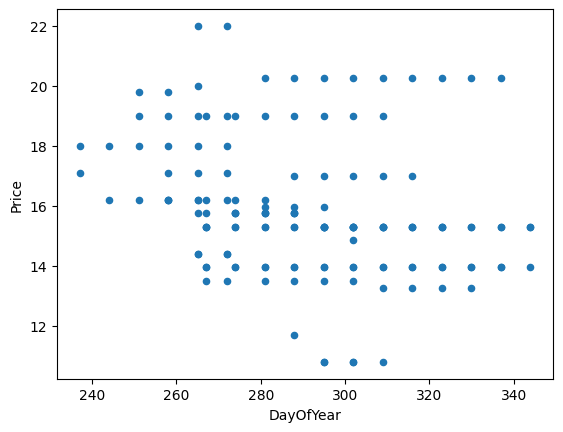

In [23]:
pie_pumpkins = new_pumpkins[new_pumpkins['Variety']=='PIE TYPE']
pie_pumpkins.plot.scatter('DayOfYear','Price')
pie_pumpkins.dropna(inplace=True)
pie_pumpkins.info()

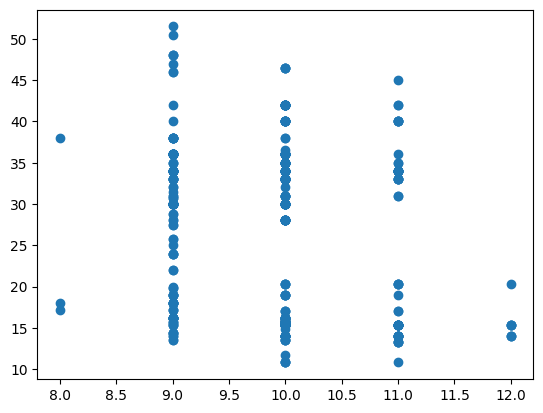

-0.14912913634278593


In [11]:
import matplotlib.pyplot as plt
price = new_pumpkins.Price
month = new_pumpkins.Month
plt.scatter(month, price)
plt.show()

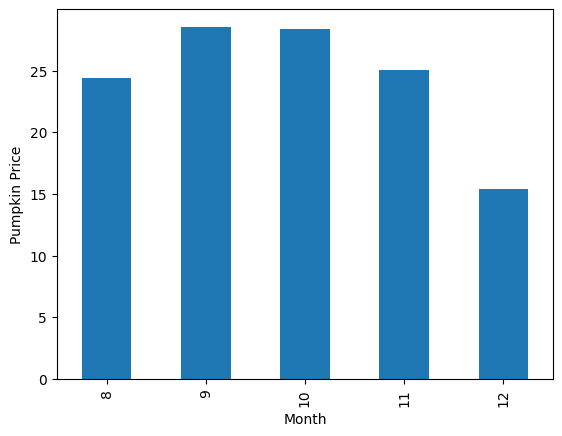

In [6]:
new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')
plt.ylabel("Pumpkin Price")
plt.xlabel("Month")

plt.show()

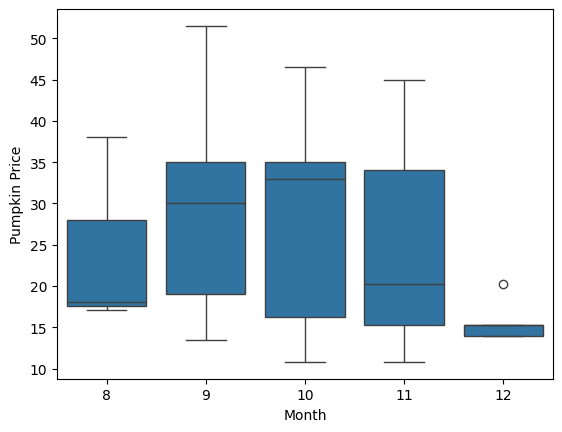

In [7]:
import seaborn as sns
sns.boxplot(x='Month', y='Price', data=new_pumpkins)
plt.ylabel("Pumpkin Price")
plt.xlabel("Month")
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [26]:
X = pie_pumpkins['DayOfYear'].to_numpy().reshape(-1,1)
y = pie_pumpkins['Price']
X.shape
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [27]:
lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

LinearRegression()

In [31]:
pred = lin_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,pred))
print(f'RMSE: {rmse:3.3} ({rmse/np.mean(pred)*100:3.3}%)')

RMSE: 2.76 (17.3%)


In [32]:
score = lin_reg.score(X_train,y_train)
print('Model determination: ', score)

Model determination:  0.04499342423558461


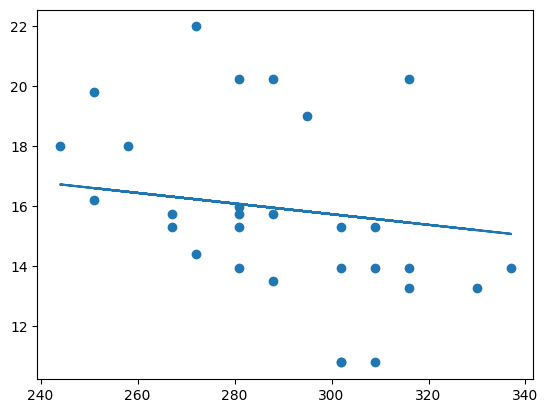

In [33]:
plt.scatter(X_test,y_test)
plt.plot(X_test,pred)